## 1. Load and Preprocess the MNIST Dataset

(60000, 28, 28)
Training data shape: (60000, 784)
Test data shape: (10000, 784)


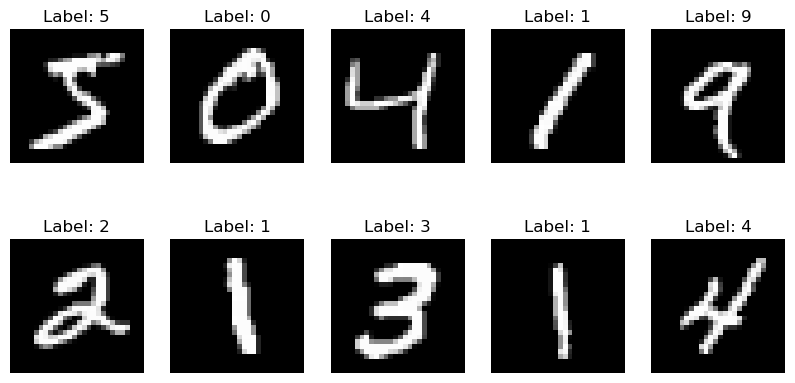

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

#Comment: Load the MNIST dataset into training and testing sets, then 
#print the shape of x_train to verify the datasets structure for 60,000 images of size 28x28).
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)

#Comment:  we normalize pixel values here and then divide by 255.0 to scale the pixel values to the range [0, 1].
# this has to be done for consistant input scaling along with keeping the values small during training 
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


#Comment: Flattening the 2D images into 1D arrays so that theyre compatible with denser layers.
# X_train.shape[0] gives the number of samples, ensuring the reshaped data matches the model's input format.
X_train = X_train.reshape(X_train.shape[0], 28*28)
X_test = X_test.reshape(X_test.shape[0], 28*28)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

#Comment: Visualizing the first 10 images in the training set, then
# creating a 2x5 grid of subplots, each displaying a 28x28 image from X_train.
# Titles show the corresponding label from y_train, and axes are turned off for clarity.
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


In [2]:
!pip install tensorflow

  Using cached rich-13.9.4-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/390.3 MB ? eta -:--:--
   - -------------------------------------- 11.0/390.3 MB 57.2 MB/s eta 0:00:07
   -- ------------------------------------- 25.4/390.3 MB 64.4 MB/s eta 0:00:06
   ---- ----------------------------------- 39.6/390.3 MB 66.2 MB/s eta 0:00:06
   ----- ---------------------------------- 53.2/390.3 MB 66.4 MB/s eta 0:00:06
   ------ --------------------------------- 67.1/390.3 MB 66.8 MB/s eta 0:00:05
   ------- -------------------------------- 77.6/390.3 MB 65.1 MB/s eta 0:00:05
   --------- ------------------------------ 93.3/390.3 MB 66.9 MB/s eta 0:00:05
   ---------- ---------------------------- 107.5/390.3 MB 67.3 MB/s eta 0:00:05
   ------------ -------------------------- 120.8/390.3 MB 67.1 MB/s eta 0:00:05
   ------------

## Build the Neural Network Model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Build the neural network model
#Write you code here. Define "model" using Sequential, Input and Dense
model = Sequential([
    Dense(8, activation='relu', input_shape=(784,)),  # hidden layer 
    Dense(10, activation='softmax')                  # Output layerr
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │         6,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,370 (24.88 KB)

 Trainable params: 6,370 (24.88 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Neural Network

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 465us/step - accuracy: 0.7123 - loss: 0.9628 - val_accuracy: 0.9061 - val_loss: 0.3355
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 413us/step - accuracy: 0.9050 - loss: 0.3334 - val_accuracy: 0.9140 - val_loss: 0.3056
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 421us/step - accuracy: 0.9165 - loss: 0.2986 - val_accuracy: 0.9218 - val_loss: 0.2812
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step - accuracy: 0.9189 - loss: 0.2823 - val_accuracy: 0.9234 - val_loss: 0.2737
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step - accuracy: 0.9230 - loss: 0.2734 - val_accuracy: 0.9246 - val_loss: 0.2709
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 434us/step - accuracy: 0.9262 - loss: 0.2608 - val_accuracy: 0.9254 - val_loss: 0.2671
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 417us/step - accuracy: 0.9266 - loss: 0.2564 - val_accuracy: 0.9279 - val_loss: 0.2610
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 412us/step - accuracy: 0.9293 -

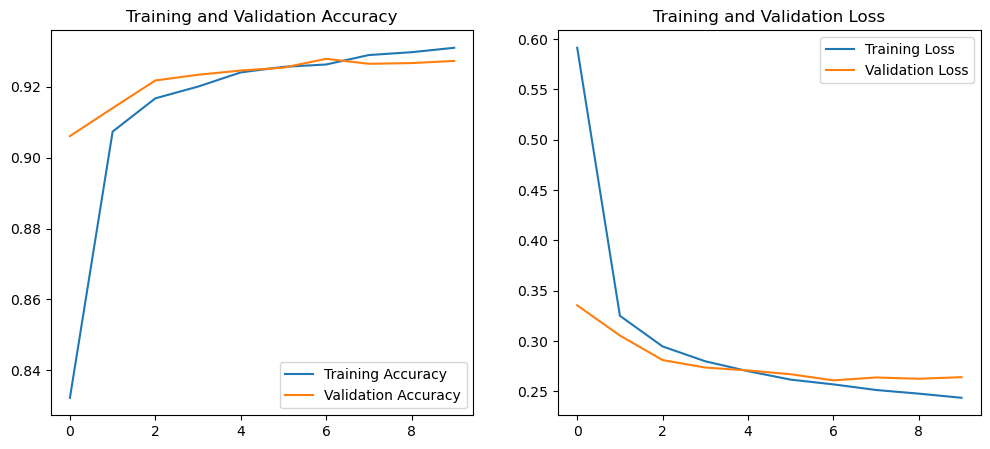

In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

#Comment:  Compile the model with Adam optimizer, sparse categorical crossentropy loss for integer labels, and accuracy metric.
model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Comment:  Save the best model during training based on highest validation accuracy.
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

#Comment:  Train the model for 10 epochs with a batch size of 32 and use validation data for monitoring.
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, callbacks=[checkpoint])

#Comment:  Plotting the training and validation accuracy across epochs, where accuracy is tracking the model during each epoch
#and the valaccuracy tracks its validations during each
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

#Comment: Plot training and validation loss over epochs to compare model performance on both datasets.
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Evaluate the Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 0.9186 - loss: 0.2948
Test Accuracy: 0.9279
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.97      0.97      1135
           2       0.91      0.92      0.91      1032
           3       0.90      0.91      0.90      1010
           4       0.92      0.94      0.93       982
           5       0.92      0.89      0.91       892
           6       0.95      0.94      0.94       958
           7       0.94      0.92      0.93      1028
           8       0.90      0.89      0.90       974
           9       0.92      0.91      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



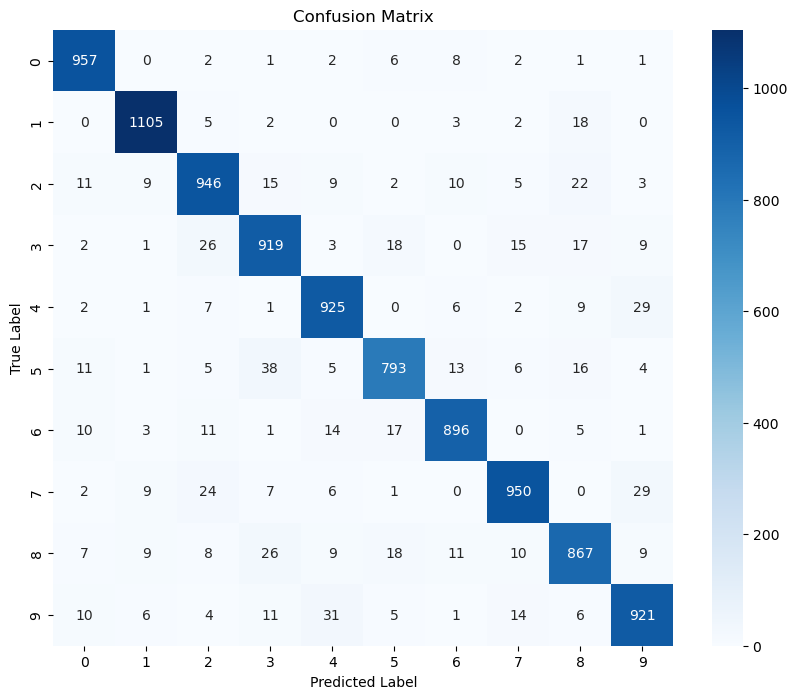

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


best_model = tf.keras.models.load_model('best_model.keras')

#Comment: eval the best saved model on the test set then print accuracy.
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

#Comment: predict the classes for the test data and generate a classification report that provides
# detailed evaluation metrics (precision, recall, F1-score, and support) for each class.
#which in turn lets us analyze the performance across all the classes
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

#Comment: generates a confusion matrix to compare and contrast the predicted vs true labels.
cm = confusion_matrix(y_test, y_pred_classes)

#Comment:plot the confusion matrix as a heatmap to visualize model performance on test data. 
#the matrix shows counts of correct and incorrect predictions, with labels for each class (0-9) on the axes. 
#the heatmap makes it easy to spot misclassifications and assess prediction accuracy visually.
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [12]:
!pip install seaborn

## Visualize Predictions

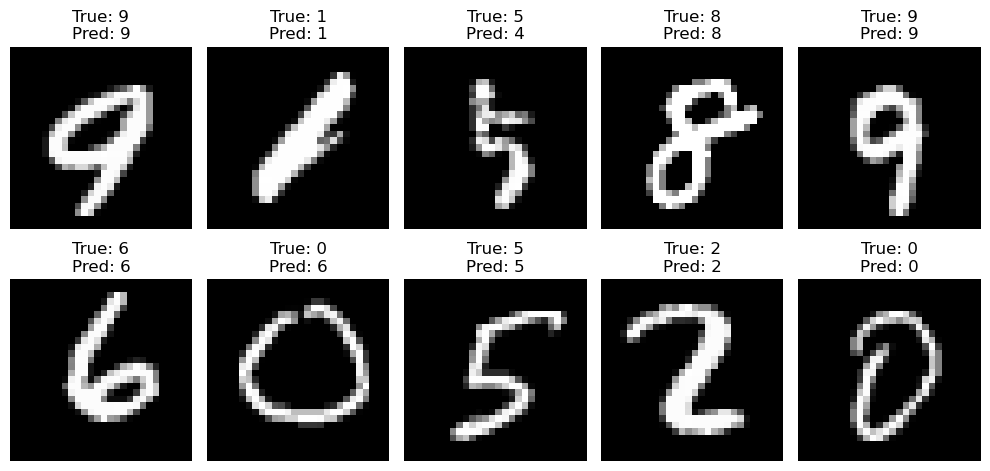

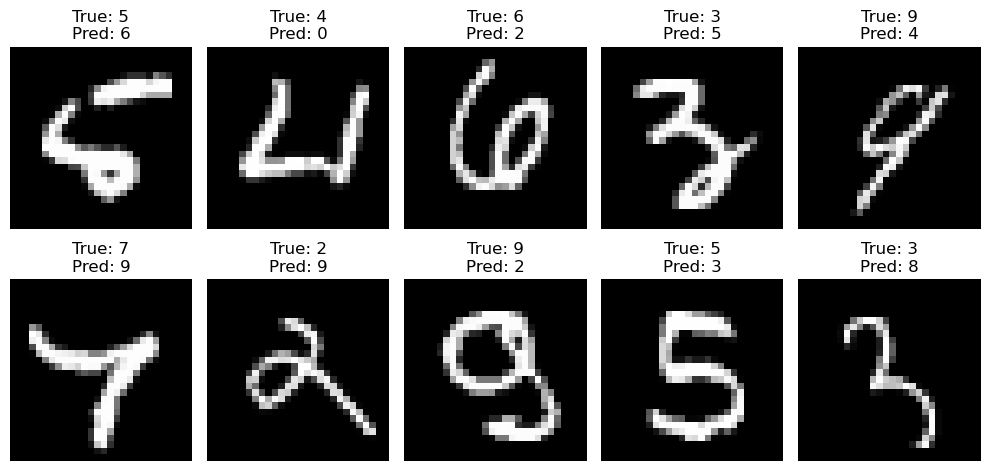

In [14]:
#Comment:randomly select 10 samples from the test set for visualization.
indices = np.random.choice(len(X_test), 10, replace=False)

#Comment: plot the randomly selected samples with their true and predicted labels.
# Each subplot shows the 28x28 grayscale image, the true label, and the predicted label.
plt.figure(figsize=(10, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

#Comment: find the indices of incorrectly classified samples.
incorrect_indices = np.where(y_test != y_pred_classes)[0]

#Comment: plot the first 10 incorrectly classified samples with their true and predicted labels.
#helps visualize specific cases where the model made errors.
plt.figure(figsize=(10, 5))
for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
